In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime

In [5]:
# ---- example usage ----
era5 = xr.open_zarr("/glade/derecho/scratch/yqsun/PANGU-S2S/ERA5/era5-benchX",chunks={}).rename({"lat": "latitude", "lon": "longitude", "plev":"level"})
# era5 = xr.open_dataset("/project/pedramh/bing/PanguWeather/v2.0/data/2018_180x360.nc", chunks={}).expand_dims(plev=1).rename({"lat": "latitude", "lon": "longitude", "plev":"level"})
era5['latitude'] = era5['latitude'].astype("float32")
era5['longitude'] = era5['longitude'].astype("float32")
era5['level'] = era5['level'].astype("int32")
# # ---- example usage ----
# era5 = xr.open_dataset("/project/pedramh/bing/PanguWeather/v2.0/data/2018_180x360.nc", chunks={})
# era5 = era5.expand_dims(plev=1).rename({"lat": "latitude", "lon": "longitude", "plev":"level"})
def preprocess(ds):
    ens = np.int32(ds.encoding["source"].split("/")[-1].split(".")[0].split("_")[-1])
    ds = ds.expand_dims(dim={"number": [ens]})
    ds = ds.rename({"time":"prediction_timedelta"})
    ds = ds.expand_dims(dim={"time": [ds["prediction_timedelta"][0].values]})
    ds["prediction_timedelta"] = np.arange(0, 24*len(ds["prediction_timedelta"]), 24).astype("timedelta64[h]").astype("timedelta64[ns]")
    return ds

In [6]:

def get_initialization_dates(year):
    """
    Get initialization dates (Calendar dates corresponding to 
    Mondays and Thursdays of 2024 May-July) for a given year.
    """
    # Define date range from May 1 to July 31 of 2024 (template)
    start_date = datetime.datetime(2024, 5, 1)
    end_date = datetime.datetime(2024, 7, 31)
    date_range = pd.date_range(start_date, end_date, freq='D')
    
    # Find Mondays (weekday=0) and Thursdays (weekday=3)
    is_monday = date_range.weekday == 0
    is_thursday = date_range.weekday == 3
    filtered_dates = date_range[is_monday | is_thursday]
    
    # Convert to the requested year
    filtered_dates_yr = pd.to_datetime(filtered_dates.strftime(f'{year}-%m-%d'))
    return filtered_dates_yr
dates= get_initialization_dates(2019)

In [29]:
sel_dates = [str(date)[:4] + str(date)[5:7] + str(date)[8:10]   for date in dates]

In [30]:
sel_dates

['20190502',
 '20190506',
 '20190509',
 '20190513',
 '20190516',
 '20190520',
 '20190523',
 '20190527',
 '20190530',
 '20190603',
 '20190606',
 '20190610',
 '20190613',
 '20190617',
 '20190620',
 '20190624',
 '20190627',
 '20190701',
 '20190704',
 '20190708',
 '20190711',
 '20190715',
 '20190718',
 '20190722',
 '20190725',
 '20190729']

In [59]:
# ds = era5["2m_temperature"]
# ds = ds.rename({"latitude": "lat", "longitude": "lon"})

# ds['lat'].attrs = {'units': 'degrees_north'}
# ds['lon'].attrs = {'units': 'degrees_east'}
# ds.to_netcdf("/glade/derecho/scratch/bgong/era5/2m_temperature.nc")
# #cdo remapcon,fuxi_s2s.txt /glade/derecho/scratch/bgong/era5/2m_temperature.nc /glade/derecho/scratch/bgong/era5/2m_temperature_121_240.nc
# # Try to extract lat/lon as 1D (if possible)
# era5 = xr.open_dataset("/glade/derecho/scratch/bgong/era5/z500_121_240.nc")
era5 = xr.open_dataset("/glade/derecho/scratch/bgong/era5/2m_temperature_121_240.nc")
# era5_t2m=era5_t2m.rename({"lat": "latitude", "lon": "longitude"})


In [7]:
date = "20210728"
number = 1
var_name = "t2m"
ds = xr.open_mfdataset(f"/glade/campaign/univ/uchi0018/bing/fuxi/{date}/member/{number:02d}/*.nc")
var = ds.sel(channel=["t2m"])

In [ ]:
#ds_ens = xr.open_mfdataset("/glade/campaign/univ/uchi0018/bing/fuxi/20180502/member/*/*.nc",combine="by_coords")
#files = [f"/glade/campaign/univ/uchi0018/bing/fuxi/20180502/member/{ens:02d}/{fcast:02d}.nc" for ens in range(1, 30) for fcast in range(1, 42)]

In [15]:
var

<xarray.Dataset> Size: 5MB
Dimensions:                        (time: 1, lead_time: 42, channel: 1,
                                    lat: 121, lon: 240)
Coordinates:
  * time                           (time) datetime64[ns] 8B 2019-05-02
  * lead_time                      (lead_time) int64 336B 1 2 3 4 ... 40 41 42
  * channel                        (channel) <U4 16B 'z500'
  * lat                            (lat) float64 968B 90.0 88.5 ... -88.5 -90.0
  * lon                            (lon) float64 2kB 0.0 1.5 3.0 ... 357.0 358.5
Data variables:
    __xarray_dataarray_variable__  (time, lead_time, channel, lat, lon) float32 5MB dask.array<chunksize=(1, 1, 1, 121, 240), meta=np.ndarray>

In [9]:
var = ds.sel(channel=["t2m"])
var["lead_time"] = var['lead_time'] * np.timedelta64(24, 'h')
# print("leadtime:", leadtime)
gt = era5.sel(time=(var.time + var["lead_time"]))

In [10]:
gt

<xarray.Dataset> Size: 1GB
Dimensions:                                (time: 1, lead_time: 42,
                                            latitude: 180, longitude: 360,
                                            level: 17)
Coordinates:
  * latitude                               (latitude) float32 720B -89.5 ... ...
  * longitude                              (longitude) float32 1kB 0.0 ... 359.0
  * level                                  (level) int32 68B 5 10 ... 925 1000
    time                                   (time, lead_time) datetime64[ns] 336B ...
  * lead_time                              (lead_time) timedelta64[s] 336B 1 ...
Data variables: (12/16)
    10m_u_component_of_wind                (time, lead_time, latitude, longitude) float32 11MB dask.array<chunksize=(1, 42, 180, 360), meta=np.ndarray>
    10m_v_component_of_wind                (time, lead_time, latitude, longitude) float32 11MB dask.array<chunksize=(1, 42, 180, 360), meta=np.ndarray>
    2m_temperature                         (time, lead_time, latitude, longitude) float32 11MB dask.array<chunksize=(1, 42, 180, 360), meta=np.ndarray>
    geopotential                           (time, lead_time, level, latitude, longitude) float32 185MB dask.array<chunksize=(1, 42, 17, 180, 360), meta=np.ndarray>
    mean_sea_level_pressure                (time, lead_time, latitude, longitude) float32 11MB dask.array<chunksize=(1, 42, 180, 360), meta=np.ndarray>
    mean_top_net_long_wave_radiation_flux  (time, lead_time, latitude, longitude) float32 11MB dask.array<chunksize=(1, 42, 180, 360), meta=np.ndarray>
    ...                                     ...
    surface_pressure                       (time, lead_time, latitude, longitude) float32 11MB dask.array<chunksize=(1, 42, 180, 360), meta=np.ndarray>
    temperature                            (time, lead_time, level, latitude, longitude) float32 185MB dask.array<chunksize=(1, 42, 17, 180, 360), meta=np.ndarray>
    total_precipitation_24hr               (time, lead_time, latitude, longitude) float32 11MB dask.array<chunksize=(1, 42, 180, 360), meta=np.ndarray>
    u_component_of_wind                    (time, lead_time, level, latitude, longitude) float32 185MB dask.array<chunksize=(1, 42, 17, 180, 360), meta=np.ndarray>
    v_component_of_wind                    (time, lead_time, level, latitude, longitude) float32 185MB dask.array<chunksize=(1, 42, 17, 180, 360), meta=np.ndarray>
    volumetric_soil_water_layer_1          (time, lead_time, latitude, longitude) float32 11MB dask.array<chunksize=(1, 42, 180, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    description:  Prediction from pangu_plasim model run 8001
    history:      Wed Apr 09 12:50:46 2025: cdo seltimestep,1 ../2018/pangu_p...

In [ ]:
# var.to_array().values[0,0,:,0,:,:]
# gt.to_array().values[0,0,:,:,:]
#np.sqrt(np.mean((var.to_array().values[0,0,:,0,:,:] - gt.to_array().values[0,0,:,:,:])**2,axis=(1,2)))

ens mean: (42,)
Figure is saved


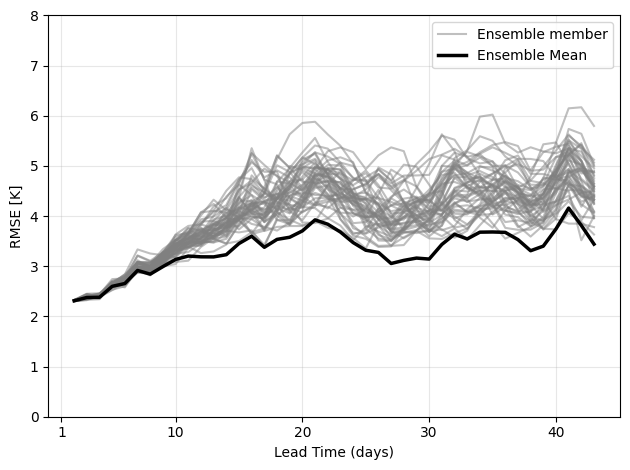

In [64]:
fig, ax = plt.subplots()
x = np.arange(1, 43)
rmse = []

for number in range(1,50):
   ds = xr.open_mfdataset(f"/glade/campaign/univ/uchi0018/bing/fuxi/{date}/member/{number:02d}/*.nc")
   var = ds.sel(channel=[var_name])
   time = var.time
   var["lead_time"] = var['lead_time'] * np.timedelta64(24, 'h')
   gt = era5.sel(time=(var.time + var["lead_time"]))
   var = var.drop_vars('channel')
   fcast = var.to_array().values[0,0,:,0,:,:]
   tr = gt.to_array().values[0,0,:,:,:]
   member_y =  np.sqrt(np.mean((fcast  - tr) **2,axis=(1,2)))
   if number == 1:
      ax.plot(x, member_y, color='gray', alpha=0.5, label="Ensemble member")
   else:
      ax.plot(x, member_y, color='gray', alpha=0.5)
   # plt.ylim(0, 2500) 
   plt.ylim(0, 8) 
   rmse.append(fcast)
ens_mean = np.array(rmse).mean(axis=0)
member_ens = np.sqrt(np.mean((ens_mean - tr)**2, axis=(1,2)))
print("ens mean:", member_ens.shape)
ax.plot(x, member_ens,color='black', linewidth=2.5, label="Ensemble Mean")

plt.xticks([0, 9, 19, 29, 39], ["1", "10", "20", "30", "40"])
plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE [K]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.show()
plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/fuxi_{date}_{var_name}_ensemble_rmse.png", dpi=300, bbox_inches="tight")
print("Figure is saved")
plt.show()


In [38]:
var 

<xarray.Dataset> Size: 5MB
Dimensions:                        (time: 1, lead_time: 42, channel: 1,
                                    lat: 121, lon: 240)
Coordinates:
  * time                           (time) datetime64[ns] 8B 2019-05-02
  * lead_time                      (lead_time) timedelta64[s] 336B 1 days ......
  * lat                            (lat) float64 968B 90.0 88.5 ... -88.5 -90.0
  * lon                            (lon) float64 2kB 0.0 1.5 3.0 ... 357.0 358.5
Dimensions without coordinates: channel
Data variables:
    __xarray_dataarray_variable__  (time, lead_time, channel, lat, lon) float32 5MB dask.array<chunksize=(1, 1, 1, 121, 240), meta=np.ndarray>

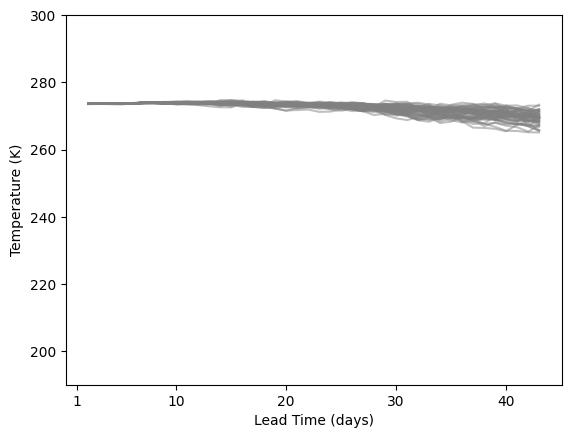

In [12]:
fig, ax = plt.subplots()
x = np.arange(1, 43)
for number in range(1,50):
    ds = xr.open_mfdataset(f"/glade/campaign/univ/uchi0018/bing/fuxi/{date}/member/{number:02d}/*.nc")
    var = ds.sel(channel=[var_name])
    member_y = var.isel(time=0,channel=0,lat=2,lon=1).to_array()[0][:42]
    ax.plot(x, member_y, color='gray', alpha=0.5)
    # plt.ylim(44000, 60000) 
    plt.ylim(190, 300)
# rmse.append(member_y)
var["lead_time"] = var['lead_time'] * np.timedelta64(24, 'h')
gt = era5.sel(time=(var.time + var["lead_time"]))
gt_mem  = gt.to_array().values[0,0,:,2,1]
ax.plot(x,gt_mem, color='black', linewidth=2.5, label="Ensemble Mean")
plt.xticks([0, 9, 19, 29, 39], ["1", "10", "20", "30", "40"])
plt.xlabel("Lead Time (days)")
# plt.ylabel(r'Geopotential (m$^2$/s$^2$)')
plt.ylabel("Temperature (K)")   # correct unit
plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/fuxi_{date}_{var_name}_location.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
dates

DatetimeIndex(['2019-05-02', '2019-05-06', '2019-05-09', '2019-05-13',
               '2019-05-16', '2019-05-20', '2019-05-23', '2019-05-27',
               '2019-05-30', '2019-06-03', '2019-06-06', '2019-06-10',
               '2019-06-13', '2019-06-17', '2019-06-20', '2019-06-24',
               '2019-06-27', '2019-07-01', '2019-07-04', '2019-07-08',
               '2019-07-11', '2019-07-15', '2019-07-18', '2019-07-22',
               '2019-07-25', '2019-07-29'],
              dtype='datetime64[ns]', freq=None)

In [74]:
import glob
# Example: list all directories under a path that start with "gencast"
dirs = glob.glob("/glade/campaign/univ/uchi0018/bing/fuxi/201905*/")

In [75]:
dirs

['/glade/campaign/univ/uchi0018/bing/fuxi/20190516/',
 '/glade/campaign/univ/uchi0018/bing/fuxi/20190519/',
 '/glade/campaign/univ/uchi0018/bing/fuxi/20190505/',
 '/glade/campaign/univ/uchi0018/bing/fuxi/20190530/',
 '/glade/campaign/univ/uchi0018/bing/fuxi/20190523/',
 '/glade/campaign/univ/uchi0018/bing/fuxi/20190526/',
 '/glade/campaign/univ/uchi0018/bing/fuxi/20190512/',
 '/glade/campaign/univ/uchi0018/bing/fuxi/20190502/',
 '/glade/campaign/univ/uchi0018/bing/fuxi/20190509/']

In [82]:
import os
all_dates = []
for path in dirs:
    all_mem = []
    for number in range(1,30):
        subdir = f"member/{number:02d}/*.nc"
        print(path)
        print("subdir,",subdir)
        file_path = os.path.join(path,subdir)
        print("file path",file_path)
        ds = xr.open_mfdataset(file_path)
        var = ds.sel(channel=["t2m"])
        time = var.time
        var["lead_time"] = var['lead_time'] * np.timedelta64(24, 'h')
        gt = era5.sel(time=(var.time + var["lead_time"]))
        var = var.drop_vars('channel')
        fcast = var.to_array().values[0,0,:,0,:,:]
        tr = gt.to_array().values[0,0,:,:,:]
        member_y =  np.sqrt(np.mean((fcast  - tr) **2,axis=(1,2)))
        all_mem.append(fcast)
    ens_mean = np.array(all_mem).mean(axis=0)
    member_ens = np.sqrt(np.mean((ens_mean - tr)**2, axis=(1,2)))
    all_dates.append(member_ens)
    




/glade/campaign/univ/uchi0018/bing/fuxi/20190516/
subdir, member/01/*.nc
file path /glade/campaign/univ/uchi0018/bing/fuxi/20190516/member/01/*.nc
/glade/campaign/univ/uchi0018/bing/fuxi/20190516/
subdir, member/02/*.nc
file path /glade/campaign/univ/uchi0018/bing/fuxi/20190516/member/02/*.nc
/glade/campaign/univ/uchi0018/bing/fuxi/20190516/
subdir, member/03/*.nc
file path /glade/campaign/univ/uchi0018/bing/fuxi/20190516/member/03/*.nc
/glade/campaign/univ/uchi0018/bing/fuxi/20190516/
subdir, member/04/*.nc
file path /glade/campaign/univ/uchi0018/bing/fuxi/20190516/member/04/*.nc
/glade/campaign/univ/uchi0018/bing/fuxi/20190516/
subdir, member/05/*.nc
file path /glade/campaign/univ/uchi0018/bing/fuxi/20190516/member/05/*.nc
/glade/campaign/univ/uchi0018/bing/fuxi/20190516/
subdir, member/06/*.nc
file path /glade/campaign/univ/uchi0018/bing/fuxi/20190516/member/06/*.nc
/glade/campaign/univ/uchi0018/bing/fuxi/20190516/
subdir, member/07/*.nc
file path /glade/campaign/univ/uchi0018/bing/

In [84]:
np.array(all_dates).shape

(9, 42)

In [85]:
avg = np.mean(np.array(all_dates),axis=0)

In [87]:
np.save("ensemble_mean_fuxi.npy", avg)

In [ ]:
"/member/{number:02d}/*.nc".format(number=1)

SyntaxError: incomplete input (3094477979.py, line 1)